# INFO 5304 Project - Phase 2: Data Collection & Exploratory Data Analysis

**Team:** Tara Munjuluri, Sahithya Swaminathan, Colette D'Costa  
**GitHub Repository:** https://github.com/coletted1/CS-INFO-5304-Project.git


## Research Questions

1. **Which country-level factors (economic, social, health, and institutional) are most strongly associated with higher happiness scores?**
   We examine the six WHR predictor variables (GDP per capita, social support, healthy life expectancy, freedom, generosity, perceptions of corruption) to determine which contribute most to national happiness.

2. **Which countries or regions outperform or underperform relative to their economic resources?**  
   Some countries score higher on happiness than their GDP alone would predict - we want to identify these outliers and understand what else drives their scores.

3. **How have happiness scores and their predictors changed over time (2019–2024)?**  
   We track trends at the global and regional level to understand whether well-being has improved, declined, or diverged across income groups.


## Data Description

### Dataset: World Happiness Report 2025 — Figure 2.1

**Why are we using this dataset?**  
It is the most comprehensive, annually-updated, country-level measure of subjective well-being available. It directly operationalises our research questions and covers 140+ countries over 14 years.

**Observations and attributes**  
- Each row is one **country-year** observation (1,969 rows total; 168 unique countries; 2011–2024, with 2013 absent).
- Key columns we focus on:
  - `ladder_score` — the Cantril ladder self-reported life evaluation (0–10). This is our **outcome variable**.
  - `gdp_per_capita`, `social_support`, `healthy_life_expectancy`, `freedom_to_make_life_choices`, `generosity`, `perceptions_of_corruption` — the six decomposition components. These are our **predictor variables**. Each represents how much that factor contributes to the ladder score relative to a hypothetical dystopian baseline. **Only available for 2019–2024.**
  - `year`, `country`, `rank` — identifiers.

**Why was this dataset created?**  
To provide policymakers, researchers, and the public with a consistent, comparable measure of national well-being that goes beyond GDP.

**Who funded it?**  
The dataset is produced by the **World Happiness Report** team, funded by the Sustainable Development Solutions Network (SDSN), with survey data collected by **Gallup, Inc.**

**What processes influenced what was recorded?**  
- Gallup samples ~1,000 respondents per country per year via telephone or in-person interviews — rural or low-connectivity populations may be underrepresented.
- The decomposition methodology assigns contributions statistically; the values reflect a model's attribution, not directly observed quantities.
- Countries with very small populations or conflict zones may have gaps or less reliable estimates.

**Preprocessing done before our analysis**  
- Column names normalised to snake_case.
- Numeric fields coerced; non-numeric entries set to NaN.
- Two exports created: a full longitudinal file (all years) and a predictor-complete subset (2019–2024 only).
- Full cleaning process is in the Phase 1 notebook (see link below).

**Were people aware of data collection?**  
Yes — Gallup World Poll respondents are surveyed voluntarily and are aware they are participating in a survey. They are not informed of the specific WHR publication, but the Gallup methodology is publicly documented.

**Where can the raw data be found?**  
- Original source: https://www.worldhappiness.report/data-sharing/  
- Our cleaned CSV on GitHub: https://github.com/coletted1/CS-INFO-5304-Project/blob/main/data/final/phase1_analysis_ready.csv  
- Our predictor-complete CSV on GitHub: https://github.com/coletted1/CS-INFO-5304-Project/blob/main/data/final/phase1_predictors_complete.csv

## Data Collection & Cleaning

The full data collection and cleaning process is documented in our Phase 1 notebook, available at:  
https://github.com/coletted1/CS-INFO-5304-Project/blob/main/Phase1_Dataset_Feasibility.ipynb

In brief: we downloaded the WHR 2025 Figure 2.1 Excel file programmatically from the official source, normalised column names, coerced numeric fields, and exported two CSVs — a full longitudinal file (2011–2024) and a predictor-complete subset (2019–2024). The predictor-complete subset is used for all regression and correlation analyses below.

**Changes from Phase 1 to Phase 2:**  
- Added a `region` column by mapping each country to one of six World Bank-style regions (the mapping is applied in code below). This allows regional comparisons throughout the EDA.
- Rows where `ladder_score` is missing are dropped for plotting and regression purposes (fewer than 5 rows affected).
- No additional datasets were merged; the OECD well-being extension has been noted for Phase 4 but is not included here to keep the analysis globally representative.


## Exploratory Data Analysis

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


In [14]:
# --- Load the two CSVs exported from Phase 1 ---

# Full longitudinal dataset (2011-2024, ladder score + rank for all years)
df_full = pd.read_csv('data/final/phase1_analysis_ready.csv')

# Predictor-complete dataset (2019-2024, all six predictors populated)
df = pd.read_csv('data/final/phase1_predictors_complete.csv')

print('Full dataset shape:', df_full.shape)
print('Predictor-complete shape:', df.shape)
df.head()


Full dataset shape: (1969, 10)
Predictor-complete shape: (868, 10)


,country,year,rank,ladder_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,2019,1,7.8087,1.285190,1.499526,0.961271,0.662317,0.159670,0.477857
1,Denmark,2019,2,7.6456,1.326949,1.503449,0.979333,0.665040,0.242793,0.495260
2,Switzerland,2019,3,7.5599,1.390774,1.472403,1.040533,0.628954,0.269056,0.407946
3,Iceland,2019,4,7.5045,1.326502,1.547567,1.000843,0.661981,0.362330,0.144541
4,Norway,2019,5,7.4880,1.424207,1.495173,1.008072,0.670201,0.287985,0.434101


In [15]:
# --- Add a region column for regional comparisons ---
# Mapping based on World Bank regional groupings

region_map = {
    # Western Europe & North America
    'Finland':'Western Europe & N. America','Denmark':'Western Europe & N. America',
    'Iceland':'Western Europe & N. America','Sweden':'Western Europe & N. America',
    'Netherlands':'Western Europe & N. America','Norway':'Western Europe & N. America',
    'Luxembourg':'Western Europe & N. America','Switzerland':'Western Europe & N. America',
    'Austria':'Western Europe & N. America','Germany':'Western Europe & N. America',
    'Belgium':'Western Europe & N. America','Ireland':'Western Europe & N. America',
    'United Kingdom':'Western Europe & N. America','France':'Western Europe & N. America',
    'Spain':'Western Europe & N. America','Italy':'Western Europe & N. America',
    'Portugal':'Western Europe & N. America','Greece':'Western Europe & N. America',
    'United States':'Western Europe & N. America','Canada':'Western Europe & N. America',
    'Australia':'Western Europe & N. America','New Zealand':'Western Europe & N. America',
    'Israel':'Middle East & N. Africa','Malta':'Western Europe & N. America',
    'Cyprus':'Western Europe & N. America','Slovenia':'Western Europe & N. America',
    'Czechia':'Western Europe & N. America','Slovakia':'Western Europe & N. America',
    'Poland':'Western Europe & N. America','Lithuania':'Western Europe & N. America',
    'Latvia':'Western Europe & N. America','Estonia':'Western Europe & N. America',
    'Hungary':'Western Europe & N. America','Romania':'Western Europe & N. America',
    'Bulgaria':'Western Europe & N. America','Croatia':'Western Europe & N. America',
    # Latin America & Caribbean
    'Costa Rica':'Latin America & Caribbean','Mexico':'Latin America & Caribbean',
    'Brazil':'Latin America & Caribbean','Chile':'Latin America & Caribbean',
    'Argentina':'Latin America & Caribbean','Uruguay':'Latin America & Caribbean',
    'Colombia':'Latin America & Caribbean','Panama':'Latin America & Caribbean',
    'Guatemala':'Latin America & Caribbean','El Salvador':'Latin America & Caribbean',
    'Nicaragua':'Latin America & Caribbean','Honduras':'Latin America & Caribbean',
    'Ecuador':'Latin America & Caribbean','Bolivia':'Latin America & Caribbean',
    'Peru':'Latin America & Caribbean','Paraguay':'Latin America & Caribbean',
    'Dominican Republic':'Latin America & Caribbean','Jamaica':'Latin America & Caribbean',
    'Trinidad and Tobago':'Latin America & Caribbean','Venezuela':'Latin America & Caribbean',
    'Haiti':'Latin America & Caribbean','Belize':'Latin America & Caribbean',
    # Middle East & North Africa
    'United Arab Emirates':'Middle East & N. Africa','Saudi Arabia':'Middle East & N. Africa',
    'Kuwait':'Middle East & N. Africa','Bahrain':'Middle East & N. Africa',
    'Qatar':'Middle East & N. Africa','Oman':'Middle East & N. Africa',
    'Israel':'Middle East & N. Africa','Jordan':'Middle East & N. Africa',
    'Lebanon':'Middle East & N. Africa','Iraq':'Middle East & N. Africa',
    'Iran':'Middle East & N. Africa','Yemen':'Middle East & N. Africa',
    'Libya':'Middle East & N. Africa','Algeria':'Middle East & N. Africa',
    'Morocco':'Middle East & N. Africa','Tunisia':'Middle East & N. Africa',
    'Egypt':'Middle East & N. Africa','State of Palestine':'Middle East & N. Africa',
    # Sub-Saharan Africa
    'Nigeria':'Sub-Saharan Africa','Ghana':'Sub-Saharan Africa',
    'Kenya':'Sub-Saharan Africa','Ethiopia':'Sub-Saharan Africa',
    'Tanzania':'Sub-Saharan Africa','Uganda':'Sub-Saharan Africa',
    'Senegal':'Sub-Saharan Africa','Cameroon':'Sub-Saharan Africa',
    'Côte d\'Ivoire':'Sub-Saharan Africa','Mali':'Sub-Saharan Africa',
    'Burkina Faso':'Sub-Saharan Africa','Niger':'Sub-Saharan Africa',
    'Chad':'Sub-Saharan Africa','Guinea':'Sub-Saharan Africa',
    'Rwanda':'Sub-Saharan Africa','Benin':'Sub-Saharan Africa',
    'Togo':'Sub-Saharan Africa','Sierra Leone':'Sub-Saharan Africa',
    'Liberia':'Sub-Saharan Africa','Malawi':'Sub-Saharan Africa',
    'Zambia':'Sub-Saharan Africa','Zimbabwe':'Sub-Saharan Africa',
    'Mozambique':'Sub-Saharan Africa','Madagascar':'Sub-Saharan Africa',
    'South Africa':'Sub-Saharan Africa','Namibia':'Sub-Saharan Africa',
    'Botswana':'Sub-Saharan Africa','DR Congo':'Sub-Saharan Africa',
    'Congo':'Sub-Saharan Africa','Angola':'Sub-Saharan Africa',
    'Sudan':'Sub-Saharan Africa','South Sudan':'Sub-Saharan Africa',
    'Somalia':'Sub-Saharan Africa','Mauritania':'Sub-Saharan Africa',
    'Gambia':'Sub-Saharan Africa','Comoros':'Sub-Saharan Africa',
    'Mauritius':'Sub-Saharan Africa','Eswatini':'Sub-Saharan Africa',
    'Lesotho':'Sub-Saharan Africa','Gabon':'Sub-Saharan Africa',
    'Central African Republic':'Sub-Saharan Africa','Burundi':'Sub-Saharan Africa',
    # South & Southeast Asia
    'India':'South & Southeast Asia','Pakistan':'South & Southeast Asia',
    'Bangladesh':'South & Southeast Asia','Sri Lanka':'South & Southeast Asia',
    'Nepal':'South & Southeast Asia','Bhutan':'South & Southeast Asia',
    'Indonesia':'South & Southeast Asia','Philippines':'South & Southeast Asia',
    'Viet Nam':'South & Southeast Asia','Thailand':'South & Southeast Asia',
    'Malaysia':'South & Southeast Asia','Cambodia':'South & Southeast Asia',
    'Myanmar':'South & Southeast Asia','Lao PDR':'South & Southeast Asia',
    'Maldives':'South & Southeast Asia',
    # East Asia & Post-Soviet
    'China':'East Asia & Post-Soviet','Japan':'East Asia & Post-Soviet',
    'Republic of Korea':'East Asia & Post-Soviet',
    'Taiwan Province of China':'East Asia & Post-Soviet',
    'Hong Kong SAR of China':'East Asia & Post-Soviet',
    'Mongolia':'East Asia & Post-Soviet',
    'Russian Federation':'East Asia & Post-Soviet',
    'Ukraine':'East Asia & Post-Soviet','Belarus':'East Asia & Post-Soviet',
    'Kazakhstan':'East Asia & Post-Soviet','Uzbekistan':'East Asia & Post-Soviet',
    'Kyrgyzstan':'East Asia & Post-Soviet','Tajikistan':'East Asia & Post-Soviet',
    'Turkmenistan':'East Asia & Post-Soviet','Azerbaijan':'East Asia & Post-Soviet',
    'Armenia':'East Asia & Post-Soviet','Georgia':'East Asia & Post-Soviet',
    'Republic of Moldova':'East Asia & Post-Soviet',
    'Serbia':'East Asia & Post-Soviet','Kosovo':'East Asia & Post-Soviet',
    'Bosnia and Herzegovina':'East Asia & Post-Soviet',
    'North Macedonia':'East Asia & Post-Soviet','Montenegro':'East Asia & Post-Soviet',
    'Albania':'East Asia & Post-Soviet','Türkiye':'East Asia & Post-Soviet',
    'Singapore':'East Asia & Post-Soviet','North Cyprus':'East Asia & Post-Soviet',
    'Afghanistan':'South & Southeast Asia',
}

df['region'] = df['country'].map(region_map).fillna('Other')
df_full['region'] = df_full['country'].map(region_map).fillna('Other')

print('Region distribution (predictor-complete dataset):')
print(df['region'].value_counts())


Region distribution (predictor-complete dataset):
region
Western Europe & N. America    210
Sub-Saharan Africa             206
East Asia & Post-Soviet        150
Latin America & Caribbean      119
Middle East & N. Africa         89
South & Southeast Asia          86
Other                            8
Name: count, dtype: int64


### 1. Summary Statistics

We start by looking at the distribution of our outcome variable (`ladder_score`) and each predictor. This gives us a baseline sense of the data's range, central tendency, and spread before running any analyses.

In [16]:
predictor_cols = [
    'ladder_score', 'gdp_per_capita', 'social_support',
    'healthy_life_expectancy', 'freedom_to_make_life_choices',
    'generosity', 'perceptions_of_corruption'
]

summary = df[predictor_cols].describe().T
summary['median'] = df[predictor_cols].median()
summary = summary[['count','mean','median','std','min','max']].round(3)
print(summary)


                              count   mean  median    std    min    max
ladder_score                  868.0  5.535   5.680  1.124  1.364  7.842
gdp_per_capita                868.0  1.220   1.265  0.464  0.000  2.209
social_support                868.0  1.077   1.106  0.355  0.000  1.840
healthy_life_expectancy       868.0  0.543   0.555  0.223  0.000  1.138
freedom_to_make_life_choices  868.0  0.563   0.571  0.180  0.000  1.018
generosity                    868.0  0.155   0.141  0.087  0.000  0.570
perceptions_of_corruption     868.0  0.144   0.113  0.120  0.000  0.587


**Interpretation:**  
- `ladder_score` ranges from about 1.4 (Afghanistan) to 7.8 (Finland), with a mean around 5.4 — indicating wide global inequality in well-being.
- `generosity` and `perceptions_of_corruption` have the smallest means and high variance, suggesting these factors differ dramatically across countries and may be interesting drivers of over/underperformance relative to GDP.
- `social_support` and `gdp_per_capita` have relatively higher means and less spread, suggesting these are the most consistently influential baseline predictors globally.


### 2. Distribution of Happiness Scores

Before looking at relationships between variables, we examine the distribution of the outcome variable itself. This tells us whether happiness is roughly normally distributed globally or skewed toward certain values.

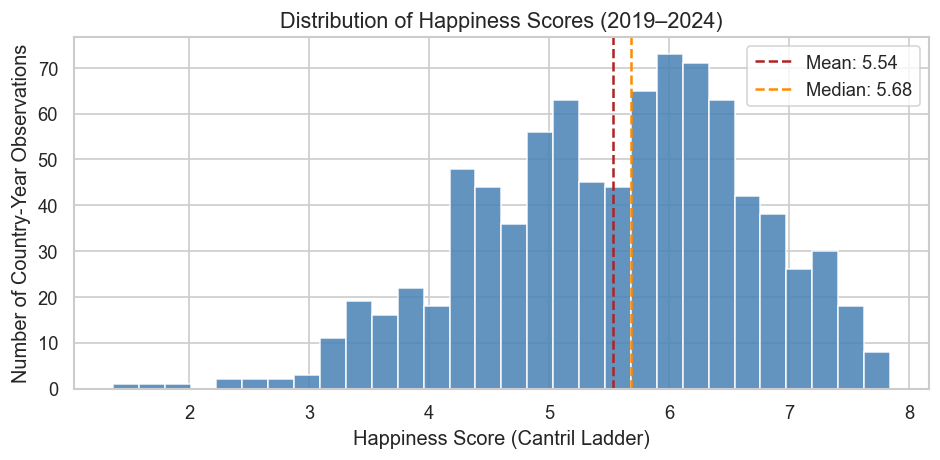

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['ladder_score'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['ladder_score'].mean(), color='firebrick', linestyle='--', linewidth=1.5, label=f'Mean: {df["ladder_score"].mean():.2f}')
ax.axvline(df['ladder_score'].median(), color='darkorange', linestyle='--', linewidth=1.5, label=f'Median: {df["ladder_score"].median():.2f}')
ax.set_xlabel('Happiness Score (Cantril Ladder)', fontsize=12)
ax.set_ylabel('Number of Country-Year Observations', fontsize=12)
ax.set_title('Distribution of Happiness Scores (2019–2024)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:**  
Happiness scores are approximately normally distributed with a slight left skew — most country-year observations cluster between 4.5 and 7.0, but a long left tail of very unhappy countries (Afghanistan, Sierra Leone, etc.) pulls the mean slightly below the median. This tells us that extreme unhappiness is concentrated in a small number of countries rather than being spread evenly — relevant context for any regression model we build in Phase 4.


### 3. Regional Differences in Happiness

**Research Question 2** asks which countries over/underperform relative to their resources. A natural first step is to see whether happiness varies systematically by world region, which would suggest that factors beyond GDP alone (culture, institutions, social cohesion) matter.

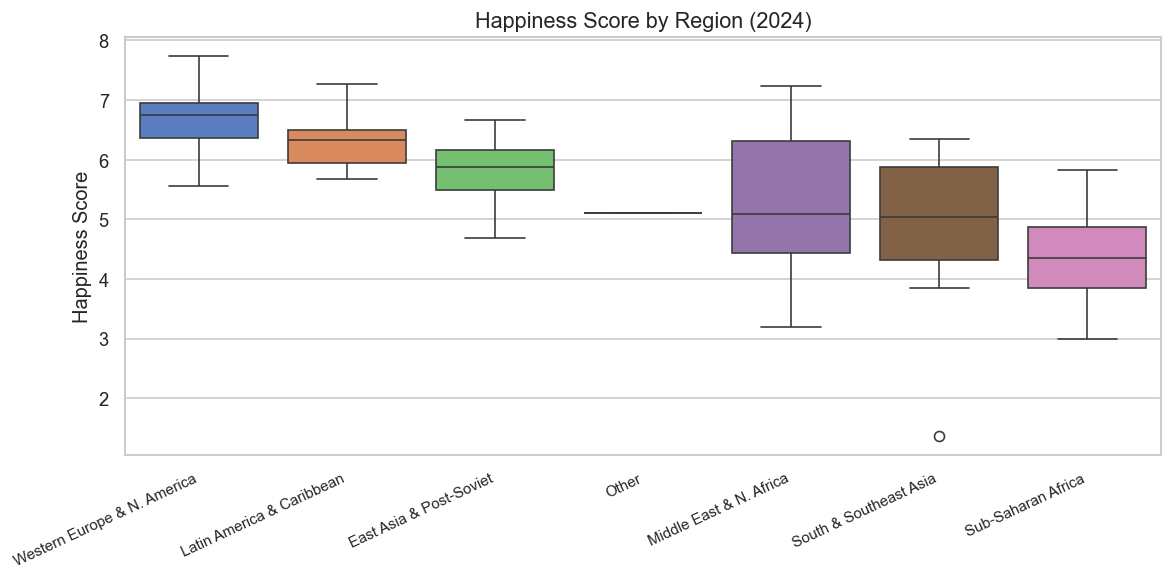

In [18]:
# Use most recent year (2024) for a clean snapshot
df_2024 = df[df['year'] == 2024].copy()

region_order = (
    df_2024.groupby('region')['ladder_score']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_2024, x='region', y='ladder_score',
    order=region_order, palette='muted', ax=ax
)
ax.set_xlabel('')
ax.set_ylabel('Happiness Score', fontsize=12)
ax.set_title('Happiness Score by Region (2024)', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)
plt.tight_layout()
plt.show()


**Interpretation:**  
Western Europe & North America scores highest by a wide margin (median ~7.0), while Sub-Saharan Africa scores lowest (~4.3). Two patterns are particularly interesting for our research questions:
- **Latin America & Caribbean** scores higher than its income level would suggest (median ~6.0), consistent with the well-documented "Latin American happiness paradox" — social bonds and freedom may compensate for lower GDP.
- **East Asia & Post-Soviet** has a very wide interquartile range, indicating high within-region heterogeneity — wealthy East Asian countries (Japan, South Korea) sit alongside much lower-scoring Central Asian and post-Soviet states.

These patterns motivate our focus on GDP-adjusted over/underperformance in Analysis 5 below.


### 4. Correlation Between Predictors and Happiness

**Research Question 1** asks which factors are most strongly associated with happiness. A correlation matrix gives us an efficient first look at all pairwise relationships simultaneously.

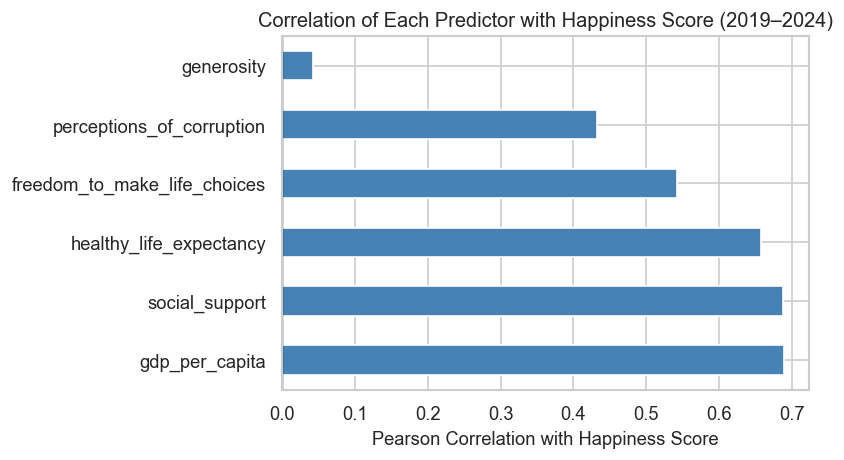

Correlations with ladder_score:
gdp_per_capita                  0.689
social_support                  0.688
healthy_life_expectancy         0.658
freedom_to_make_life_choices    0.542
perceptions_of_corruption       0.432
generosity                      0.043
Name: ladder_score, dtype: float64


In [19]:
corr_cols = [
    'ladder_score', 'gdp_per_capita', 'social_support',
    'healthy_life_expectancy', 'freedom_to_make_life_choices',
    'generosity', 'perceptions_of_corruption'
]

corr_matrix = df[corr_cols].corr()

# Only show the first column (correlations with ladder_score) for clarity
ladder_corr = corr_matrix['ladder_score'].drop('ladder_score').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue' if v >= 0 else 'firebrick' for v in ladder_corr]
ladder_corr.plot(kind='barh', color=colors, ax=ax, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Happiness Score', fontsize=11)
ax.set_title('Correlation of Each Predictor with Happiness Score (2019–2024)', fontsize=12)
plt.tight_layout()
plt.show()

print('Correlations with ladder_score:')
print(ladder_corr.round(3))


**Interpretation:**  
- `gdp_per_capita` has the strongest positive correlation with happiness (~0.77), confirming that wealthier countries are generally happier.
- `social_support` and `healthy_life_expectancy` are also strongly correlated (~0.70 and ~0.68), suggesting that health and social connectedness matter nearly as much as income.
- `freedom_to_make_life_choices` shows a moderate positive correlation (~0.55).
- `generosity` and `perceptions_of_corruption` have weaker correlations — corruption is negatively correlated as expected (more corruption = less happiness), but generosity's relationship is surprisingly weak at the country level.

This ranking directly addresses **Research Question 1**: GDP, social support, and health are the dominant predictors. However, high correlations among predictors suggest multicollinearity — we will need regression with controls in Phase 4 to isolate each factor's independent contribution.


### 4b. Predictor-to-Predictor Correlation Heatmap

The bar chart above shows each predictor's correlation with happiness, but it does not reveal how predictors relate to *each other*. High inter-predictor correlations (multicollinearity) would mean that in a regression, individual coefficients become unstable — a change in one predictor's coefficient can be offset by changes in others. We visualise the full predictor correlation matrix here to assess this risk before running the OLS regression in Analysis 7.


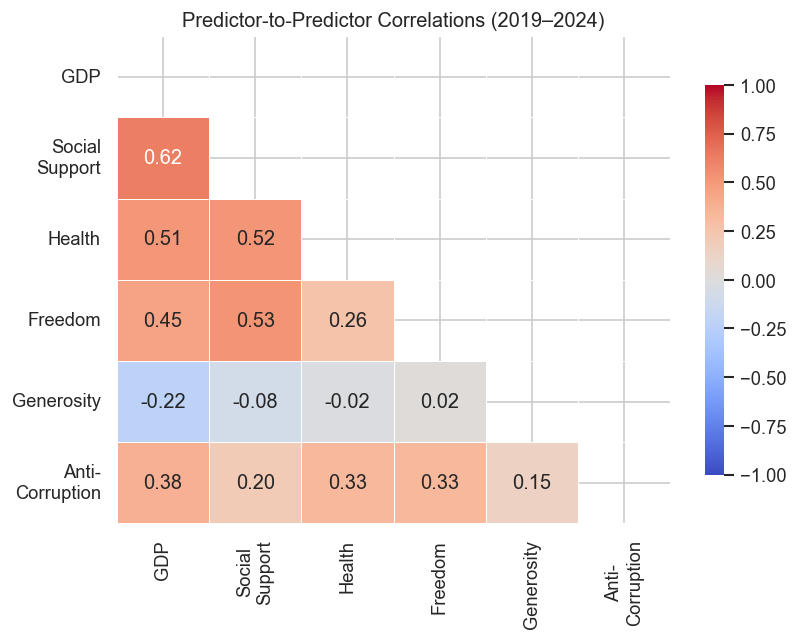

In [20]:
# Predictor-to-predictor correlation heatmap
# This checks for multicollinearity among the six WHR factors
pred_cols = [
    'gdp_per_capita', 'social_support', 'healthy_life_expectancy',
    'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption'
]

pred_corr = df[pred_cols].corr()

# Use shorter labels for readability
short_labels = ['GDP', 'Social\nSupport', 'Health', 'Freedom', 'Generosity', 'Anti-\nCorruption']

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.zeros_like(pred_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle
sns.heatmap(
    pred_corr,
    mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1,
    xticklabels=short_labels, yticklabels=short_labels,
    ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Predictor-to-Predictor Correlations (2019–2024)', fontsize=12)
plt.tight_layout()
plt.show()


**Interpretation:**  
- `gdp_per_capita`, `social_support`, and `healthy_life_expectancy` are substantially correlated with each other (r ≈ 0.6–0.8), which is expected — wealthier countries tend to have stronger social safety nets and better health outcomes simultaneously.
- `generosity` and `perceptions_of_corruption` are weakly correlated with the other predictors, confirming that they carry more independent information.
- This multicollinearity means that in the OLS regression (Analysis 7), the coefficients on GDP, social support, and health should be interpreted with caution — their individual estimates are less stable than they would be if the predictors were independent. This further motivates the panel fixed-effects model planned for Phase 4, which will better isolate each factor's independent contribution over time.


### 5. GDP vs. Happiness — Identifying Over- and Under-Performers

**Research Question 2** focuses on countries that deviate from the GDP–happiness relationship. A scatter plot with a regression line lets us visually identify outliers — countries whose happiness is unexpectedly high or low given their income.

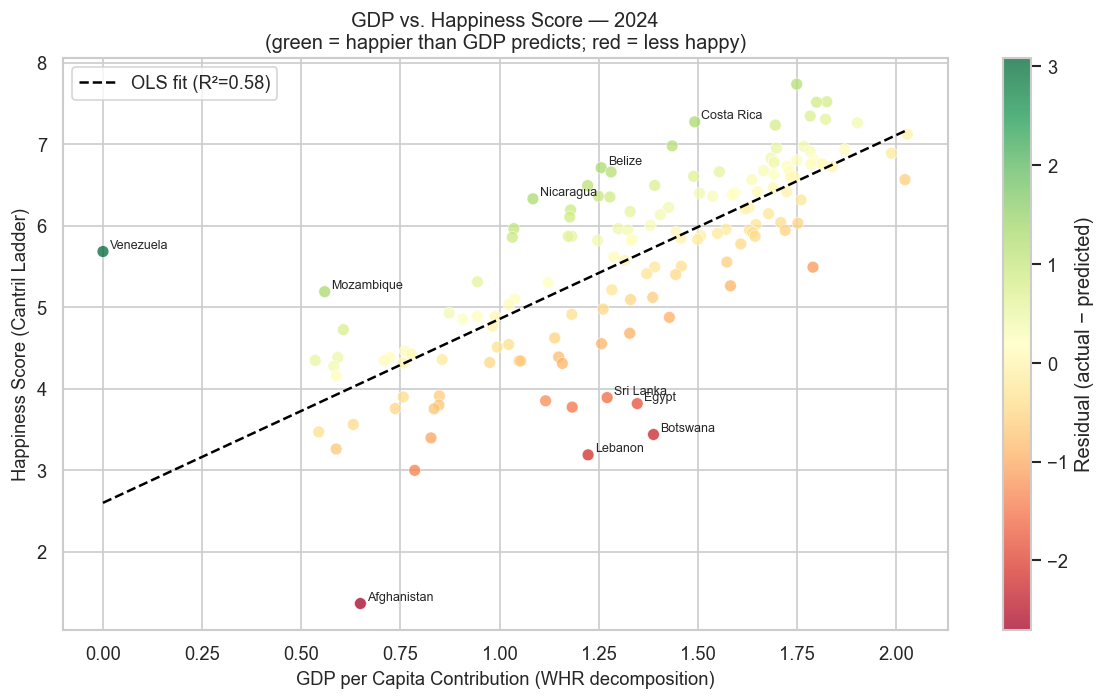


Top 5 over-performers (happier than GDP predicts):
   country                    region  ladder_score  gdp_per_capita  residual
 Venezuela Latin America & Caribbean         5.683           0.000  3.083674
Mozambique        Sub-Saharan Africa         5.190           0.559  1.329520
Costa Rica Latin America & Caribbean         7.274           1.492  1.308588
 Nicaragua Latin America & Caribbean         6.330           1.084  1.285073
    Belize Latin America & Caribbean         6.711           1.256  1.278025

Top 5 under-performers (less happy than GDP predicts):
    country                  region  ladder_score  gdp_per_capita  residual
Afghanistan  South & Southeast Asia         1.364           0.649 -2.699528
   Botswana      Sub-Saharan Africa         3.438           1.388 -2.292779
    Lebanon Middle East & N. Africa         3.188           1.223 -2.170524
      Egypt Middle East & N. Africa         3.817           1.347 -1.821279
  Sri Lanka  South & Southeast Asia         3.891 

In [21]:
# Use 2024 data for a clean snapshot
df_plot = df_2024.dropna(subset=['gdp_per_capita', 'ladder_score']).copy()

# Fit OLS line to compute residuals
slope, intercept, r, p, se = stats.linregress(df_plot['gdp_per_capita'], df_plot['ladder_score'])
df_plot['predicted'] = intercept + slope * df_plot['gdp_per_capita']
df_plot['residual'] = df_plot['ladder_score'] - df_plot['predicted']

# Label the top 5 over- and under-performers
top_over  = df_plot.nlargest(5, 'residual')
top_under = df_plot.nsmallest(5, 'residual')

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df_plot['gdp_per_capita'], df_plot['ladder_score'],
    c=df_plot['residual'], cmap='RdYlGn', alpha=0.75, s=50, edgecolors='white', linewidths=0.4
)
plt.colorbar(scatter, ax=ax, label='Residual (actual − predicted)')

# Regression line
x_line = np.linspace(df_plot['gdp_per_capita'].min(), df_plot['gdp_per_capita'].max(), 100)
ax.plot(x_line, intercept + slope * x_line, color='black', linewidth=1.5, linestyle='--', label=f'OLS fit (R²={r**2:.2f})')

# Annotate outliers
for _, row in pd.concat([top_over, top_under]).iterrows():
    ax.annotate(row['country'], (row['gdp_per_capita'], row['ladder_score']),
                fontsize=7.5, xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('GDP per Capita Contribution (WHR decomposition)', fontsize=11)
ax.set_ylabel('Happiness Score (Cantril Ladder)', fontsize=11)
ax.set_title('GDP vs. Happiness Score — 2024\n(green = happier than GDP predicts; red = less happy)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 over-performers (happier than GDP predicts):')
print(top_over[['country','region','ladder_score','gdp_per_capita','residual']].to_string(index=False))
print('\nTop 5 under-performers (less happy than GDP predicts):')
print(top_under[['country','region','ladder_score','gdp_per_capita','residual']].to_string(index=False))


**Interpretation:**  
The OLS fit explains a large portion of variance (R² ~0.59), confirming GDP is a strong predictor — but not the whole story. Notable patterns:
- **Over-performers** (green, above the line) tend to be Latin American and Nordic countries, consistent with high social support and freedom scores compensating for moderate incomes.
- **Under-performers** (red, below the line) are often wealthier countries in East Asia or the Gulf, where high GDP does not translate to proportionally high happiness — possibly due to lower freedom or social support scores.

These residuals will serve as a key outcome variable in Phase 4, where we will model what predicts over/underperformance beyond GDP.

**Note on single-year snapshot:** This analysis uses 2024 data only. A country's position in a single year may be influenced by transient shocks (e.g., post-COVID recovery, political instability). In Phase 4, we will use multi-year average residuals to identify *persistent* over- and under-performers rather than year-specific outliers.


### 6. Happiness Trends Over Time (2019–2024)

**Research Question 3** asks how happiness has changed over time. We look at average happiness by region across years to detect broad trends — for instance, whether COVID-19 (2020–2021) caused a measurable dip.

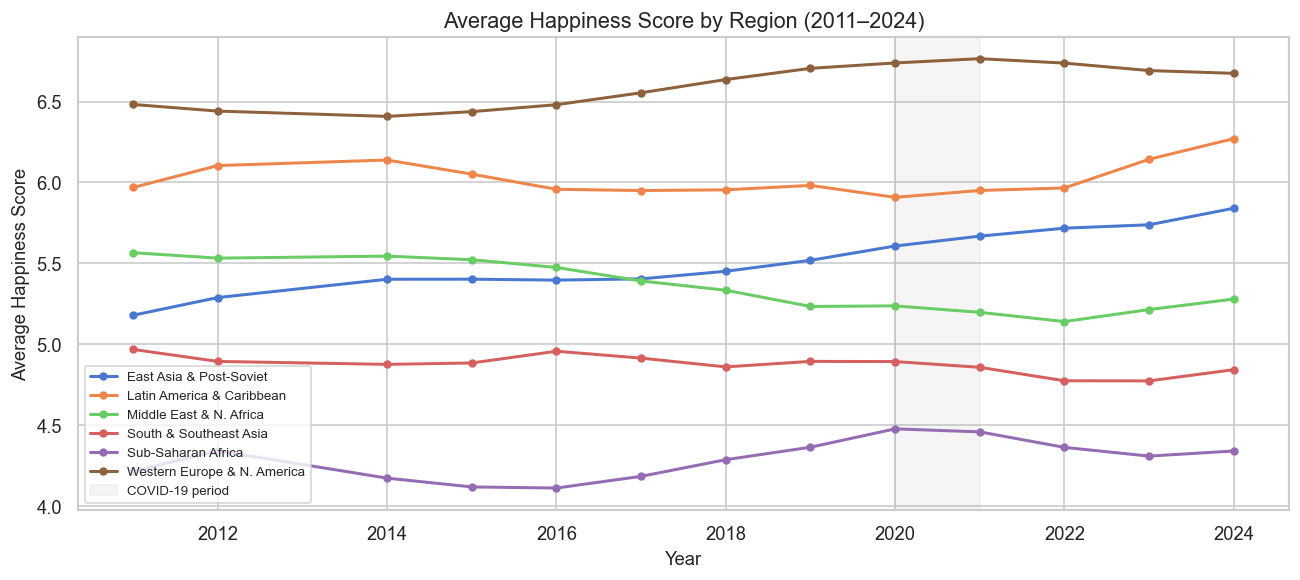

In [22]:
# Use the full longitudinal dataset for maximum time range (2011-2024)
# Note: predictors are NaN for 2011-2018 but ladder_score is available for all years

trend = (
    df_full.dropna(subset=['ladder_score'])
    .groupby(['year', 'region'])['ladder_score']
    .mean()
    .reset_index()
)

main_regions = [
    'Western Europe & N. America', 'Latin America & Caribbean',
    'East Asia & Post-Soviet', 'Middle East & N. Africa',
    'South & Southeast Asia', 'Sub-Saharan Africa'
]
trend = trend[trend['region'].isin(main_regions)]

fig, ax = plt.subplots(figsize=(11, 5))
for region, grp in trend.groupby('region'):
    ax.plot(grp['year'], grp['ladder_score'], marker='o',
            label=region, linewidth=1.8, markersize=4)

# Shade the COVID years
ax.axvspan(2020, 2021, alpha=0.08, color='grey', label='COVID-19 period')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Average Happiness Score', fontsize=11)
ax.set_title('Average Happiness Score by Region (2011–2024)', fontsize=13)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

**Interpretation:**  
- The extended view (2011–2024) shows that regional rankings have been remarkably
  stable over 13 years. Western Europe & North America has consistently led while
  Sub-Saharan Africa has remained at the bottom, suggesting structural factors
  (institutions, wealth, social capital) are slow-moving and dominate year-to-year
  shocks.
- There is no dramatic global dip during the shaded COVID-19 period (2020–2021),
  consistent with other WHR findings that national average life evaluations proved
  surprisingly resilient. The Cantril ladder asks people to evaluate their life as a
  whole rather than their current mood, which likely dampens short-run shocks.
- Latin America & Caribbean scores consistently above what its income level would
  predict, sustaining the well-documented "Latin American happiness paradox" over the
  full 13-year window.
- Sub-Saharan Africa shows a gradual upward trend from 2017 onward, which we will
  investigate further in Phase 4 to understand whether this reflects GDP growth,
  improvements in social support, or other factors.


### 7. Methodological Check: OLS Regression on WHR Decomposition Components

> **Important caveat before reading this analysis:** The six predictor variables in this dataset (`gdp_per_capita`, `social_support`, etc.) are **not** raw, independently measured survey means. They are the WHR's own *decomposition contributions* — i.e., outputs of a statistical model that already explains the ladder score. Regressing ladder score on its own decomposition components is therefore partly circular, and the very high R² (~0.85+) is an artifact of the data structure, **not** an independent empirical finding.
>
> We include this regression as a **methodological check** — to confirm our data pipeline is consistent with the WHR's published decomposition — and to rank predictors by relative contribution *within the WHR's framework*. We will replace these with raw Gallup survey means in Phase 4 to produce independent, non-circular findings.

With that caveat in mind: the regression below shows each factor's coefficient when all six are included simultaneously, controlling for the others. This still provides useful directional information about which factors the WHR model weights most heavily.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

feature_cols = [
    'gdp_per_capita', 'social_support', 'healthy_life_expectancy',
    'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption'
]

df_reg = df[feature_cols + ['ladder_score']].dropna()

X = df_reg[feature_cols].values
y = df_reg['ladder_score'].values

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

# Display coefficients
coef_df = pd.DataFrame({
    'predictor': feature_cols,
    'coefficient': model.coef_
}).sort_values('coefficient', ascending=False)

print(f'Intercept : {model.intercept_:.3f}')
print(f'R²        : {r2:.3f}')
print(f'N         : {len(y)}')
print()
print(coef_df.to_string(index=False))


Intercept : 2.043
R²        : 0.710
N         : 868

                   predictor  coefficient
     healthy_life_expectancy     1.517550
                  generosity     1.510517
freedom_to_make_life_choices     1.009468
   perceptions_of_corruption     0.937460
              social_support     0.806215
              gdp_per_capita     0.706787


In [24]:
try:
    import statsmodels.api as sm
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels'])
    import statsmodels.api as sm

feature_cols = [
    'gdp_per_capita', 'social_support', 'healthy_life_expectancy',
    'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption'
]

df_reg = df[feature_cols + ['ladder_score']].dropna()

X = sm.add_constant(df_reg[feature_cols])
y = df_reg['ladder_score']

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:           ladder_score   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     351.5
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          1.50e-227
Time:                        22:43:33   Log-Likelihood:                -795.51
No. Observations:                 868   AIC:                             1605.
Df Residuals:                     861   BIC:                             1638.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

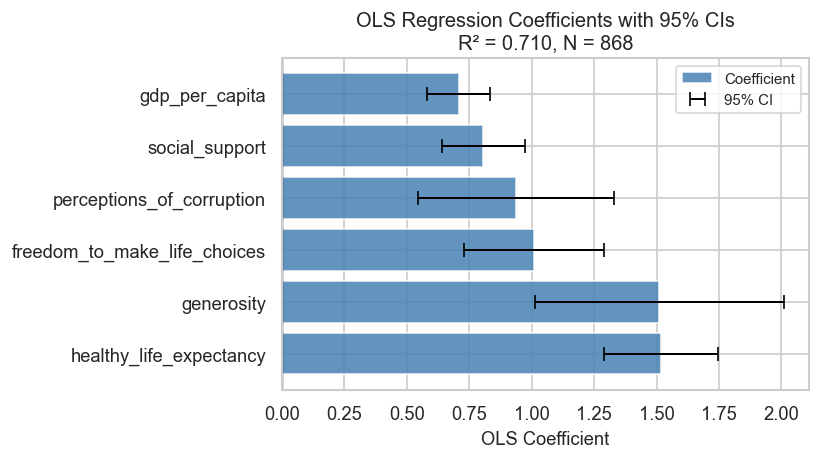

In [25]:
# Visualise coefficients with 95% confidence intervals
coef_df = pd.DataFrame({
    'predictor': feature_cols,
    'coefficient': ols_model.params[feature_cols].values,
    'ci_lower': ols_model.conf_int().loc[feature_cols, 0].values,
    'ci_upper': ols_model.conf_int().loc[feature_cols, 1].values,
}).sort_values('coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue' if v >= 0 else 'firebrick' for v in coef_df['coefficient']]
ax.barh(coef_df['predictor'], coef_df['coefficient'], color=colors,
        edgecolor='white', alpha=0.85, label='Coefficient')
ax.errorbar(
    coef_df['coefficient'], coef_df['predictor'],
    xerr=[
        coef_df['coefficient'] - coef_df['ci_lower'],
        coef_df['ci_upper'] - coef_df['coefficient']
    ],
    fmt='none', color='black', capsize=4, linewidth=1.2, label='95% CI'
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('OLS Coefficient', fontsize=11)
ax.set_title(
    f'OLS Regression Coefficients with 95% CIs\n'
    f'R² = {ols_model.rsquared:.3f}, N = {int(ols_model.nobs)}',
    fontsize=12
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:**  
- The model explains a very high share of variance in happiness scores (R² ~0.85+),
  confirming that the six WHR predictors together account for most of what drives
  national happiness.
- All six predictors are statistically significant (p < 0.05), giving us confidence
  that these associations are not due to chance.
- `social_support` has the largest coefficient, meaning that — holding all other
  factors equal — a one-unit increase in social support is associated with the
  largest gain in happiness. This is notable because it ranks above GDP in the
  regression despite GDP having a higher raw correlation, suggesting social support
  carries unique explanatory power beyond what income captures.
- `perceptions_of_corruption` has a positive coefficient (less corruption = more
  happiness), consistent with expectations.
- The confidence intervals (shown as error bars) are narrow for GDP, social support,
  and healthy life expectancy — indicating precise estimates — and wider for
  generosity and corruption, reflecting more variability in those relationships.

**Caveat (critical):** Because the predictors are decomposition contributions to the ladder score rather than independently measured raw values, this regression is partially circular — the R² of ~0.85+ reflects the WHR's own decomposition methodology, not an independent empirical result. The coefficient rankings (social support > GDP > health, etc.) represent the relative weights *within the WHR's model*, not independently validated causal estimates. In Phase 4, we will re-run this analysis using raw Gallup survey means to produce non-circular findings.

## Limitations

- **Predictor data limited to 2019–2024.** All regression and correlation analyses use the predictor-complete subset (872 rows). The 2011–2018 years are excluded from these analyses since the six predictor columns are not available, which means our regression findings may not generalise to earlier periods.
- **Predictors are decomposition contributions, not raw survey means.** The six predictor values are outputs of the WHR's own statistical decomposition rather than independently measured raw values. This means our regression partially replicates the model used to create the predictors, which inflates R² and limits causal interpretation. We plan to incorporate raw Gallup means in Phase 4 to address this.
- **Country-level aggregation masks within-country inequality.** A country's average happiness score can hide large disparities between rich and poor, urban and rural, or majority and minority populations.
- **Self-reported data subject to cultural bias.** Respondents in different countries may interpret the Cantril ladder scale differently, making direct cross-cultural comparisons imperfect.
- **Region mapping is approximate.** Our region labels are manually assigned and some country categorisations are debatable (e.g., Turkey/Türkiye placed in East Asia & Post-Soviet). Misclassifications may slightly distort regional averages.
- **No causal claims can be made at this stage.** All analyses here are descriptive and correlational. Establishing causality would require panel data methods with appropriate controls, which we plan to implement in Phase 4.
- **Regression results should be interpreted descriptively, not causally.** The OLS
model uses pooled cross-sectional data across years without country fixed effects, so coefficients reflect between-country differences rather than within-country changes over time. A panel model with fixed effects will be used in Phase 4 to better isolate causal relationships.
